# Linear Regression — Theory and Practice
### Block 1 of Phase 1 · ML-Notes-and-Projects

This notebook is my study log for linear regression, combining the theoretical foundations from *An Introduction to Statistical Learning* (ISLP, Chapters 2-3) with the hands-on implementation approach from *Hands-On Machine Learning* (HOML, Chapter 4).

Instead of using ISLP's synthetic example ($Y=2+3X+\varepsilon$), here I work with a real, public dataset: the **Ames Housing dataset** (De Cock, 2011), which contains 2930 residential property sales in Ames, Iowa, described by 82 features (numerical + categorical) plus the target variable SalePrice.

### Goals of this notebook
1. Understand and implement **Simple Linear Regression** from scratch (Normal Equation + Gradient Descent), then validate against **scikit-learn** and **statsmodels**.
2. Extend to **Multiple Linear Regression**, including categorical predictors.
3. Understand and interpret **interferential statistics**: standar errors, the t-test for individual coefficients, the F-test for overall model significance, $R^2$/ adjusted $R^2$, and confidence intervals.
4. Check the **assumptions** behind the linear model (linearity, homoscedasticity, normality of residuals, multicollinearity).

### Dataset source
Ames Housing dataset, originally compiled by Dean De Cock as a modern, ethically-sourced alternative to the Boston Housing dataset. Source CSV: https://github.com/wblakecannon/ams (mirrors the original data relased for the Kaggle House Prices competition, unsplit).

# 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

np.random.seed(42)

# 1. First Look at the Data

In [2]:
df = pd.read_csv("housing.csv")
print(df.shape)
df.head()

(2930, 83)


,Unnamed: 0,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 83 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       2930 non-null   int64  
 1   Order            2930 non-null   int64  
 2   PID              2930 non-null   int64  
 3   MS SubClass      2930 non-null   int64  
 4   MS Zoning        2930 non-null   object 
 5   Lot Frontage     2440 non-null   float64
 6   Lot Area         2930 non-null   int64  
 7   Street           2930 non-null   object 
 8   Alley            198 non-null    object 
 9   Lot Shape        2930 non-null   object 
 10  Land Contour     2930 non-null   object 
 11  Utilities        2930 non-null   object 
 12  Lot Config       2930 non-null   object 
 13  Land Slope       2930 non-null   object 
 14  Neighborhood     2930 non-null   object 
 15  Condition 1      2930 non-null   object 
 16  Condition 2      2930 non-null   object 
 17  Bldg Type     

We have 2930 observations and 82 columns (81 predictors + SalePrice). A quick check on the target variable and on missing values:

In [3]:
df["SalePrice"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

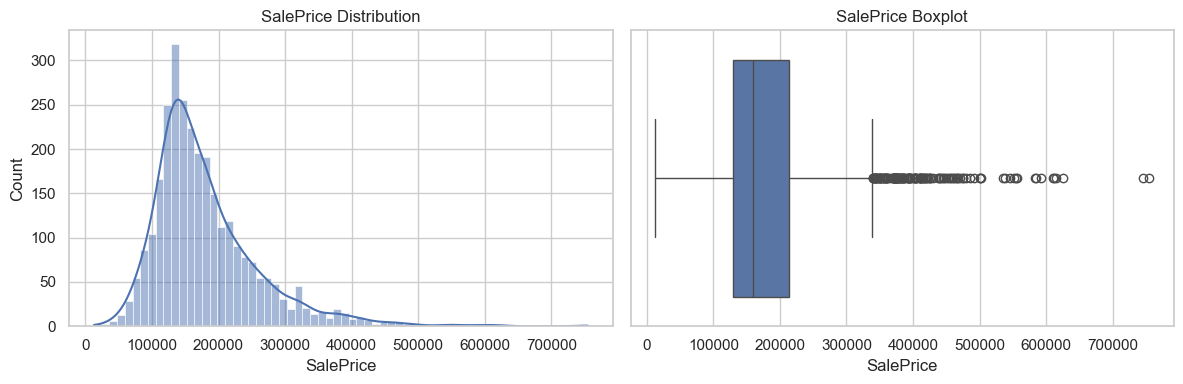

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("SalePrice Distribution")
sns.boxplot(x=df["SalePrice"], ax=axes[1])
axes[1].set_title("SalePrice Boxplot")
plt.tight_layout()
plt.show()

SalePrice is right-skewed, as is typical for price data (a handful of expensive houses pull the mean above the median). We'll keep this in mind: it can affect the normality of residuals later on, and is a common reason practitioners model $\log{(\text{SalePrice})}$ instead. For now we work with the raw scale to keep the coefficient interpretation intuitive, and revisit this in the residual diagnostics section.

### 2. Choosing a Predictor for Simple Linear Regression

Before jumping into modeling, we need to pick *one numerical predictor* for the simple linear regression case. A natural approach is to rank all numerical features by their (Pearson) correlation with SalePrice.

In [5]:
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
correlations.head(11) #top 10 + SalePrice itself

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Name: SalePrice, dtype: float64

In [6]:
top_corr = correlations.drop("SalePrice").head(10)

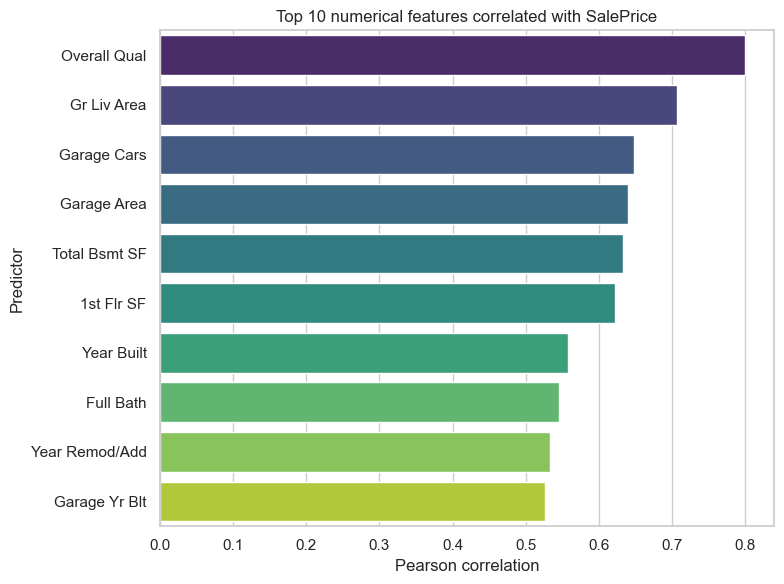

In [7]:
plt.figure(figsize=(8, 6))
sns.barplot(x=top_corr.values, y=top_corr.index, hue=top_corr.index, palette="viridis", legend=False)
plt.title("Top 10 numerical features correlated with SalePrice")
plt.xlabel("Pearson correlation")
plt.ylabel("Predictor")
plt.tight_layout()
plt.show()

Overall Qual (overall material and finish quality, rated 1-10) actually shows the strongest linear correlation with SalePrice. However, it is worth pausing on what kind of variable this really is:
* Overall Qual is encoded as an integer (int64), but it is fundamentally an **ordinary categorical variable** (a rating scale), not a continuous measurement. Treating it as continuous in a regression is common practice and often reasonable, but it means the coefficient interpretation ("one more quality point $\to$ $X$ more") assumes equally spaced effects across the 1-10 scale, which is a stronger assumption than for a variable like square footage.
* Gr Liv Area (above-ground living area, in square feet) is a genuinely **continuous** variable, has the second-highest correlation, and has a very natural real-world interpretation: *bigger house* $\to$ *higher price*.

This is why we choose **Gr Liv Area** as our predictor for simple linear regression. This keeps the first pass conceptually clean (a true continuous $X\to Y$ relationship) before we deal with the added complexity of ordinal and categorical predictors in the multiple regression section.

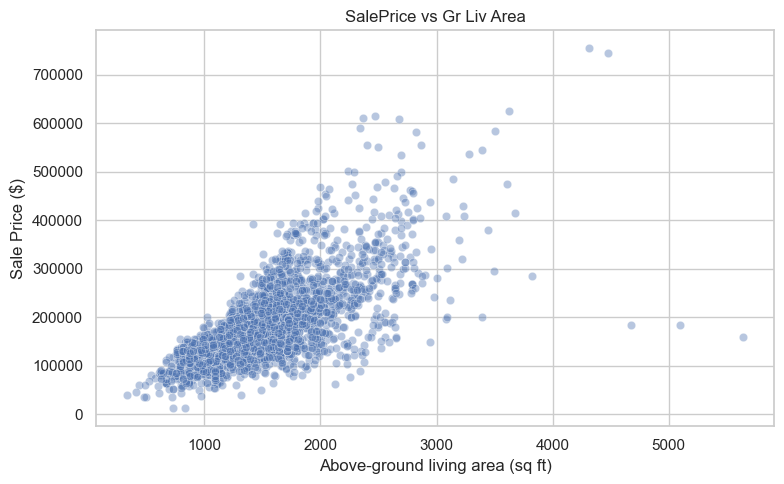

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Gr Liv Area", y="SalePrice", alpha=0.4)
plt.title("SalePrice vs Gr Liv Area")
plt.xlabel("Above-ground living area (sq ft)")
plt.ylabel("Sale Price ($)")
plt.tight_layout()
plt.show()

This relationship looks reasonably linear, with variance that appears to increase somewhat for larget houses (a first, informal hint of possible **heteroscedasticity**, which we will check formaly later with residual plots). There's also a couple of visible outliers — very large houses sold at a comparatively low price — which we'll keep in mind but not remove, to stay close to how a real dataset behaves.

Let's isolate our working variables and drop any rows with missing values in either column (there shouldn't be any here, but it's good practice to check explicitly).

In [9]:
print("Missing in Gr Liv Area:", df["Gr Liv Area"].isna().sum())
print("Missing in SalePrice:", df["SalePrice"].isna().sum())

simple_df = df[["Gr Liv Area", "SalePrice"]].dropna().reset_index(drop=True)
simple_df.describe()

Missing in Gr Liv Area: 0
Missing in SalePrice: 0


,Gr Liv Area,SalePrice
count,2930.000000,2930.000000
mean,1499.690444,180796.060068
std,505.508887,79886.692357
min,334.000000,12789.000000
25%,1126.000000,129500.000000
50%,1442.000000,160000.000000
75%,1742.750000,213500.000000
max,5642.000000,755000.000000


### Train / test split

Even though our goal here is mostly *inferential* (understanding the relationship and its statistical significance) rather than purely *predictive*, we still split into train and test sets. This lets us later evaluate how well the fitted line generalizes to unseen data — a habit worth building from the very first model onward, since in later blocks this split is not optional.

In [10]:
X = simple_df[["Gr Liv Area"]].values # keeps as 2D array: shape (n_samples, 1)
y = simple_df["SalePrice"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 2344 | Test size: 586


# 3. Simple Linear Regression


### 3.1 The model

Following ISLP (Chapter 3.1), simple linear regression assumes a linear relationship between a single predictor $X$ and a quantitative response $Y$:
$$Y=\beta_0+\beta_1X+\varepsilon$$
where:
* $\beta_0$ is the **intercept**—the expected value of $Y$ when $X=0$.
* $\beta_1$ is the **slope**—the average change in $Y$ for a one-unit increase in $X$.
* $\varepsilon$ is an **irreducible error term**, assumed to have mean zero and to be independent of $X$.

In our case: $\text{SalePrice}=\beta_0+\beta_1\cdot(\text{Gr Liv Area}) + \varepsilon$.

Since $\beta_0$ and $\beta_1$ are unknown population parameters, we estimate them from the training data as $\hat{\beta}_0$ and $\hat{\beta}_1$, producing the fitted line:
$$\hat{y}=\hat{\beta}_0+\hat{\beta}_1x$$

### 3.2 Estimating the coefficients: Ordinary Least Squares (OLS)

We choose $\hat{\beta}_0$, $\hat{\beta}_1$ to minimize the **Residual Sum of Squares (RSS)**:

$$\text{RSS}=\sum_{i=1}^n\left(y_i-\hat{y}_i\right)^2=\sum_{j=1}^n\left(y_i-\hat{\beta}_0-\hat{\beta}_1x_i\right)^2$$

Minimizing this via calculus (setting the partial derivatives with respect to $\beta_0$ and $\beta_1$ to zero), gives the well-known closed-form **least squares estimates**:
$$
\hat{\beta}_1 = \frac{\sum_{i=1}^n (x_i-\overline{x})(y_i-\overline{y})}{\sum_{i=1}^n (x_i-\overline{x})^2}, \quad \hat{\beta}_0=\overline{y}-\hat{\beta}_1\overline{x}
$$

This is essentially a special case (one predictor) of the more general **Normal Equation**, which we implement below in its matrix form so that it generalizes directly to multiple regression later on.

### 3.3 The Normal Equation (matrix form)

Let ${X}$ be the **design matrix**: an $n\times2$ matrix whose first column is all 1's (to account for the intercept $\beta_0$) and whose second column contains the values of Gr Liv Area. Let ${y}$ be the $n\times1$ vector of SalePrice values, and ${\beta}=(\beta_0,\beta_1)^T$.

The model in matrix form is ${y}={X\beta}+\varepsilon$, and RSS becomes $\text{RSS}({\beta})=({y}-{X\beta})^T({y}-{X\beta})$. 

Minimizing with respect to ${\beta}$ (setting the gradient to zero) yields the **Normal Equation**:
$$
\hat{{\beta}}= ({X}^T{X})^{-1}{X}^T{y}
$$
This gives us the exact, closed-form solution in a single step (no interation required). Its main drawback (which becomes relevant with many features) is that inverting ${X}^T{X}$ costs roughly $O(p^3)$, where $p$ is the number of predictors (fine for $p=1$, but expensive for very high.dimensional data). This is one of the motivations for Gradient Descent, which we implement in the next part.

In [11]:
# Build the design matrix X (with intercept column) and target vector y
X_b_train = np.c_[np.ones((X_train.shape[0], 1)), X_train] # add x0 = 1 to each instance
X_b_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]

print("Design matrix shape (train):", X_b_train.shape)
X_b_train[:5]

Design matrix shape (train): (2344, 2)


array([[1.000e+00, 1.370e+03],
       [1.000e+00, 2.126e+03],
       [1.000e+00, 1.224e+03],
       [1.000e+00, 1.040e+03],
       [1.000e+00, 1.701e+03]])

In [12]:
# Normal Equation, implemented byy hand with NumPy
beta_hat_normal_eq = np.linalg.inv(X_b_train.T @ X_b_train) @ X_b_train.T @ y_train

beta_0_hat, beta_1_hat = beta_hat_normal_eq
print(f"Intercept (beta_0): {beta_0_hat:,.2f}")
print(f"Slope (beta_1): {beta_1_hat:,.2f}")

Intercept (beta_0): 19,250.56
Slope (beta_1): 106.73


**Interpretation**: $\hat{\beta}_1$ tells us that, on average, each additional square foot of above-ground living area is associated with an increase of approximately $\hat{\beta}_1$ dollars in sale price, holding nothing else constant (since this is a simple, one-predictor model). $\hat{\beta}_0$ is the model's predicted price when Gr Liv Area is zero (which is not a meaningful real-world scenario, no house has zero square feet), so we treat it here mostly as a mathematical anchor for the line rather than a directly interpretable quantity.

Note: we use np.linalg.inv() here for pedagogical transparency (it mirros the formula exactly), even though in production code np.linalg.solve() or np.linalg.lstsq() is preferred for better numerical stability. We'll keep this in mind, since with more predictors (multiple regression) matrix inversion can become numerically fragile if predictors are highly correlated (multicollinearity).

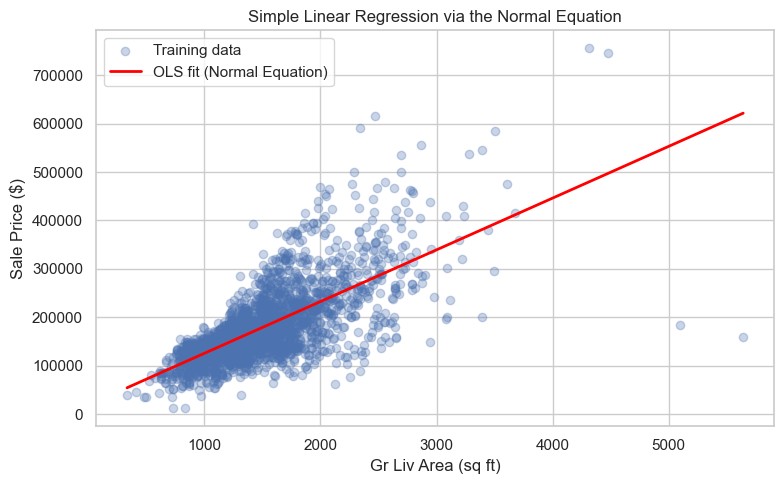

In [13]:
# Quick visual sanity check: does this line look right?
x_range = np.linspace(X_train.min(), X_train.max(), 100)
y_range_pred = beta_0_hat+beta_1_hat * x_range

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.3, label="Training data")
plt.plot(x_range, y_range_pred, color="red", linewidth=2, label="OLS fit (Normal Equation)")
plt.xlabel("Gr Liv Area (sq ft)")
plt.ylabel("Sale Price ($)")
plt.title("Simple Linear Regression via the Normal Equation")
plt.legend()
plt.tight_layout()
plt.show()

### 3.4 Gradient Descent

As mentioned above, the Normal Equation gives an exact solution but doesn't scale well when the number of features is very large, as inverting $X^TX$ is computationally expensive. **Gradient Descent (GD)** is the iterative alternative used throughout HOML (Chapter 4): instead of solving for $\hat{\beta}$ directly, we start from a random guess and repeatedly nudge it in the direction that most reduces the cost function.

**Cost funtion**. We use the **Mean Squared Error (MSE)**, which is the RSS from before divided by $n$ (this scalling doesn't change where the minimum is, it just keeps the cost function's magnitude independent of the data size):
$$
J(\beta)=\frac{1}{n}\sum_{i=1}^n \left(x_i^T\beta-y_i\right)^2
$$
**Gradient**. In matrix form, the gradient of $J$ with respect to $\beta$ is
$$
\nabla{\beta}J(\beta)=\frac{2}{n}X^T(X\beta-y)
$$
This vector points in the direction of **steepest ascent** of the cost function, so we move in the opposite direction, scaled by a **learning rate** $\eta$:
$$
\beta^{(t+1)}=\beta^{(t)}-\eta\cdot\nabla{\beta}J(\beta^{(t)})
$$
We repeat this update for a fixed number of iterations, or until de cost stops improving meaningfully.

A crucial practical detail: **featuring scaling**. Gr Liv Area ranges roughly from 300 to 5600, while SalePrice is in the hundreds of thousands. Left unscaled, Gradient Descent converges (or diverges) extremely slowly because the cost surface becomes a very elongated, narrow valley. HOML is explicit about this: **always scale features before using Gradiant Descent**. We standardize Gr Liv Area (zero mean, unit variance) purely for the optimization procedure, and convert the learned coefficients back to the original scale at the end so they remain comparable to the Normal Equation results.

In [14]:
# Standardize the predictor (fit scaler on train only, to avoid data leakage)
x_mean, x_std = X_train.mean(), X_train.std()

X_train_scaled = (X_train - x_mean) / x_std
X_test_scaled = (X_test - x_mean) / x_std

X_b_train_scaled = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]

print(f"Gr Liv Area — mean: {x_mean:.2f}, std: {x_std:.2f}")

Gr Liv Area — mean: 1492.86, std: 504.51


In [15]:
def gradient_descent(X_b, y, learning_rate=0.1, n_iterations=1000):
    """
    Batch Gradient Descent for linear regression.
    X_b : design matrix including the bias column (shape: n_samples x n_features+1)
    y   : target vector (shape: n_samples)
    Returns the learned parameter vector and the cost history.
    """
    n = len(y)
    beta = np.random.randn(X_b.shape[1]) # random initialization
    cost_history = []

    for iteration in range(n_iterations):
        predictions = X_b @ beta
        errors = predictions - y
        gradient = (2 / n) * X_b.T @ errors
        beta = beta - learning_rate * gradient

        cost = (1 / n) * np.sum(errors ** 2) # MSE
        cost_history.append(cost)

    return beta, cost_history

beta_gd_scaled, cost_history = gradient_descent(
    X_b_train_scaled, y_train, learning_rate=0.1, n_iterations=1000
)

print(f"Learned parameters (scaled space): {beta_gd_scaled}")

Learned parameters (scaled space): [178582.20776451  53846.14198601]


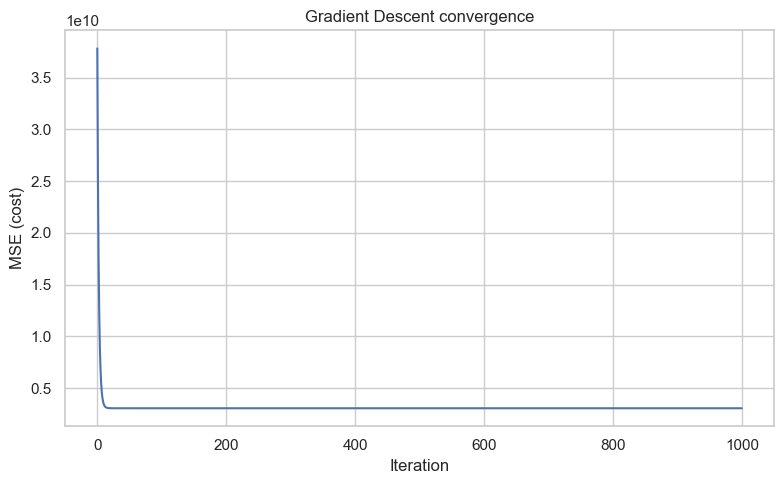

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("MSE (cost)")
plt.title("Gradient Descent convergence")
plt.tight_layout()
plt.show()

The cost drops sharply within the first handful of iterations and then flattens out (Gradient Descent has converged). Now we need to convert the learned coefficients back from the **original scale** of Gr Liv Area, so we can compare them directly against the Normal Equation results.

Since $x_{\text{scaled}}=\dfrac{x-\mu}{\sigma}$, the model $\hat{y}=\beta_0^{\text{scaled}}+\beta_1^{\text{scaled}}\cdot x_{\text{scaled}}$ becomes, after substitution and algebra:
$$
\beta_1^{\text{original}}=\frac{\beta_1^{\text{scaled}}}{\sigma}, \quad \beta_0^{\text{original}}=\beta_0^{\text{scaled}}-\beta_1^{\text{original}}\cdot\mu
$$

In [17]:
beta_0_gd_scaled, beta_1_gd_scaled = beta_gd_scaled

beta_1_gd = beta_1_gd_scaled / x_std
beta_0_gd = beta_0_gd_scaled - beta_1_gd * x_mean

print(f"Comparison — Normal Equation vs. Gradient Descent (original scale):")
print(f"{'':15s} {'Normal Eq.':>15s} {'Gradient Descent':>20s}")
print(f"{'Intercept':15s} {beta_0_hat:15,.2f} {beta_0_gd:20,.2f}")
print(f"{'Slope':15s} {beta_1_hat:15,.2f} {beta_1_gd:20,.2f}")

Comparison — Normal Equation vs. Gradient Descent (original scale):
                     Normal Eq.     Gradient Descent
Intercept             19,250.56            19,250.56
Slope                    106.73               106.73


Both methods converge to the same coefficients (small differences are due to Gradient Descent being an iterative approximation, sensitive to both the learning rate and the number of iterations, whereas the Normal Equation is exact). This is a reassuring validation: our from-scratch implementation is mathematically consistent, and we now understand why scikit-learn's and statsmodels' implementations produce these particular numbers: they are not magic, just efficient, well-tested versions of the same two ideas.